# Task 2 — Product Category Clustering

This notebook builds and inspects five product meta-categories from the Amazon review dataset. It combines **product names**, **catalog category metadata**, and **review text** instead of clustering on product titles alone. It also cleans malformed product names, keeps products with unknown names out of the clustering model, compares 4–6 cluster solutions, visualizes the five-cluster result, inspects examples, and assigns human-readable labels.

## Run instructions
1. Open this notebook in VS Code from the repository's `notebooks` folder.
2. Select the project Python environment and install dependencies with `pip install -r requirements.txt` if needed.
3. Run all cells from top to bottom. The default input is `datasets/1429_1.csv`; in Colab a file-upload option appears if that path is missing.

The notebook writes the Task 2 CSV files and charts to `outputs/`. It does not need an LLM or API key.

## Clustering design and interpretation

The unit being clustered is a **named product**, not an individual review. Review records are aggregated by cleaned product name to calculate review counts, average ratings, and sentiment shares. TF-IDF text representations are built separately for the product title, its catalog category metadata, and a deterministic sample of review text, then combined with explicit weights. Product titles receive the strongest weight; category metadata is secondary; review language contributes additional evidence.

K-Means cluster IDs are arbitrary, so they are not meaningful category names by themselves. After reviewing each cluster's representative products and terms, we assign descriptive labels. These labels reflect this dataset and this fixed seed; if you change the dataset or clustering settings, rerun the inspection and revisit the label mapping. Silhouette scores in sparse text spaces can be low, so this is exploratory grouping—not proof that product boundaries are objectively correct.

In [13]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
N_CLUSTERS = 5
sns.set_theme(style="whitegrid")
print("Imports ready")

Imports ready


## 1. Locate and load the dataset

Use the same Amazon dataset as Task 1. The Colab upload fallback is only used when the local repository file is absent.

In [14]:
cwd = Path.cwd()
ROOT = next((path for path in [cwd, *cwd.parents] if (path / "datasets").is_dir()), cwd)
DATA_DIR = ROOT / "datasets"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "1429_1.csv"

if not DATA_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            f"Dataset not found: {DATA_PATH}. Put 1429_1.csv in the datasets folder "
            "or update DATA_PATH to the correct CSV."
        ) from exc
    uploaded = files.upload()
    csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
    if not csv_files:
        raise ValueError("No CSV file was uploaded.")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    DATA_PATH = DATA_DIR / "1429_1.csv"
    DATA_PATH.write_bytes(uploaded[csv_files[0]])

raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dataset: {DATA_PATH}")
print(f"Rows: {len(raw_df):,} | columns: {len(raw_df.columns)}")
display(raw_df[["name", "categories", "reviews.text", "reviews.rating"]].head())

Dataset: datasets\1429_1.csv
Rows: 34,660 | columns: 21


,name,categories,reviews.text,reviews.rating
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",This product so far has not disappointed. My c...,5.0
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",great for beginner or experienced person. Boug...,5.0
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",Inexpensive tablet for him to use and learn on...,5.0
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",I've had my Fire HD 8 two weeks now and I love...,4.0
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",I bought this for my grand daughter when she c...,5.0


## 2. Inspect data quality and clean product names

The source has missing names and some product names repeated on multiple lines. We keep the first non-empty line as the product name, normalize whitespace, and treat blank or literal `Unknown` names as unavailable. These unnamed reviews remain in the review data but are excluded from product clustering: putting thousands of unknown-name reviews into one fake product cluster would distort the result.

In [15]:
required_columns = {"name", "categories", "reviews.text", "reviews.rating"}
missing_columns = required_columns.difference(raw_df.columns)
if missing_columns:
    raise ValueError(f"Required dataset columns are missing: {sorted(missing_columns)}")

def clean_product_name(value):
    if pd.isna(value):
        return "Unknown product"
    first_line = str(value).replace("\r", "\n").split("\n", maxsplit=1)[0]
    name = re.sub(r"\s+", " ", first_line).strip(" ,\t")
    if not name or name.lower() in {"unknown", "nan", "none"}:
        return "Unknown product"
    return name

def clean_text(value):
    if pd.isna(value):
        return ""
    text = re.sub(r"[^a-z0-9\s]", " ", str(value).lower())
    return re.sub(r"\s+", " ", text).strip()

reviews = raw_df.copy()
reviews["product_name"] = reviews["name"].map(clean_product_name)
reviews["review_text"] = reviews["reviews.text"].map(clean_text)
reviews["categories"] = reviews["categories"].fillna("").astype(str)
reviews["rating"] = pd.to_numeric(reviews["reviews.rating"], errors="coerce")
reviews = reviews.dropna(subset=["rating"]).copy()
reviews["sentiment"] = np.select(
    [reviews["rating"].le(2), reviews["rating"].eq(3), reviews["rating"].between(4, 5)],
    ["negative", "neutral", "positive"],
    default="invalid",
)
reviews = reviews.loc[reviews["sentiment"].isin(["negative", "neutral", "positive"])]
reviews = reviews.loc[reviews["review_text"].str.len().gt(0)].copy()
print(f"Usable rated reviews: {len(reviews):,}")
print(f"Reviews without a usable product name: {(reviews['product_name'] == 'Unknown product').sum():,}")
print(f"Named products before aggregation: {reviews.loc[reviews['product_name'] != 'Unknown product', 'product_name'].nunique():,}")
display(reviews[["product_name", "categories", "rating", "sentiment", "review_text"]].head())

Usable rated reviews: 34,625
Reviews without a usable product name: 6,759
Named products before aggregation: 40


,product_name,categories,rating,sentiment,review_text
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,positive,this product so far has not disappointed my ch...
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,positive,great for beginner or experienced person bough...
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,positive,inexpensive tablet for him to use and learn on...
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,positive,i ve had my fire hd 8 two weeks now and i love...
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,positive,i bought this for my grand daughter when she c...


## 3. Build one feature record per product

For each named product, calculate descriptive review statistics, collect its catalog category metadata, and prepare a deterministic sample of up to 20 review texts for the text features. Product review text helps distinguish items with similar titles, while the title and category fields keep product identity central. We also inspect the products with the most reviews to understand the dataset's coverage.

In [16]:
named_reviews = reviews.loc[reviews["product_name"] != "Unknown product"].copy()
product_rows = []
for product_name, group in named_reviews.groupby("product_name", sort=True):
    category_values = sorted({value.strip() for value in group["categories"] if value.strip()})
    review_sample = group.loc[group["review_text"].str.len().gt(0), "review_text"].head(20)
    product_rows.append({
        "product_name": product_name,
        "categories_text": " ".join(category_values),
        "review_document": " ".join(review_sample),
        "review_count": int(len(group)),
        "mean_rating": float(group["rating"].mean()),
        "negative_share": float(group["sentiment"].eq("negative").mean()),
        "neutral_share": float(group["sentiment"].eq("neutral").mean()),
        "positive_share": float(group["sentiment"].eq("positive").mean()),
    })

products = pd.DataFrame(product_rows)
if len(products) <= N_CLUSTERS:
    raise ValueError(f"Need more than {N_CLUSTERS} named products to cluster; found {len(products)}.")
print(f"Products clustered: {len(products):,}")
display(products.sort_values("review_count", ascending=False)[
    ["product_name", "review_count", "mean_rating", "negative_share"]
].head(15).style.format({"mean_rating": "{:.2f}", "negative_share": "{:.1%}"}))

Products clustered: 40


,product_name,review_count,mean_rating,negative_share
31,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",10961,4.45,3.0%
26,Echo (White),3310,4.65,1.6%
17,Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,3176,4.76,1.1%
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",2814,4.59,1.9%
13,Amazon Fire Tv,2528,4.65,1.6%
29,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",1685,4.51,3.7%
20,Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,1033,4.55,2.7%
38,"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers",580,4.74,0.7%
30,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",368,4.60,2.4%
3,Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black,318,4.73,0.9%


## 4. Convert title, catalog categories, and review text into combined TF-IDF features

Each field gets its own vocabulary and TF-IDF representation. The sparse matrices are concatenated, with title weight **4.0**, category weight **1.0**, and sampled review-text weight **0.25**. These weights prioritize product identity while allowing category and customer-language evidence to influence similarity. They are explicit analysis choices, not learned parameters.

In [17]:
title_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), max_features=1000, sublinear_tf=True
)
category_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), max_features=500, sublinear_tf=True
)
review_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), max_features=4000, sublinear_tf=True
)

title_features = title_vectorizer.fit_transform(products["product_name"]) * 4.0
category_features = category_vectorizer.fit_transform(products["categories_text"]) * 1.0
review_features = review_vectorizer.fit_transform(products["review_document"]) * 0.25
feature_matrix = hstack([title_features, category_features, review_features]).tocsr()
print(f"Combined product feature matrix: {feature_matrix.shape[0]} products × {feature_matrix.shape[1]} features")
print("Feature block dimensions:", {
    "product title": title_features.shape[1],
    "catalog categories": category_features.shape[1],
    "review text": review_features.shape[1],
})

Combined product feature matrix: 40 products × 4668 features
Feature block dimensions: {'product title': 329, 'catalog categories': 339, 'review text': 4000}


## 5. Compare solutions with 4, 5, and 6 clusters

The assignment calls for 4–6 meta-categories. We calculate inertia and cosine silhouette score for each candidate value. Silhouette helps compare separation, but with a small number of product records, overlapping products, and sparse text features, it is only one diagnostic. We use five clusters for this walkthrough and then inspect their actual contents before naming them.

,clusters,inertia,cosine silhouette
0,4,517.24,0.105
1,5,485.36,0.111
2,6,460.06,0.130


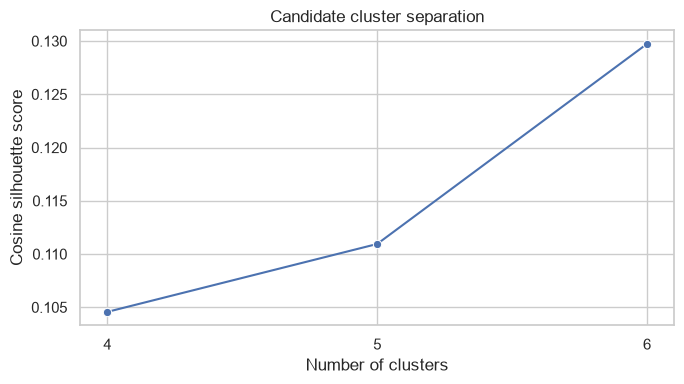

Using 5 clusters for detailed interpretation.


In [18]:
solution_rows = []
candidate_models = {}
for k in (4, 5, 6):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    cluster_ids = model.fit_predict(feature_matrix)
    candidate_models[k] = (model, cluster_ids)
    solution_rows.append({
        "clusters": k,
        "inertia": model.inertia_,
        "cosine silhouette": silhouette_score(feature_matrix, cluster_ids, metric="cosine"),
    })
solution_comparison = pd.DataFrame(solution_rows)
display(solution_comparison.style.format({"inertia": "{:.2f}", "cosine silhouette": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=solution_comparison, x="clusters", y="cosine silhouette", marker="o", ax=ax)
ax.set(title="Candidate cluster separation", xlabel="Number of clusters", ylabel="Cosine silhouette score")
ax.set_xticks([4, 5, 6])
plt.tight_layout()
plt.show()

cluster_model, cluster_ids = candidate_models[N_CLUSTERS]
products["cluster_id"] = cluster_ids
print(f"Using {N_CLUSTERS} clusters for detailed interpretation.")

## 6. Inspect cluster profiles before assigning names

For each cluster, this section calculates the number of products and represented reviews, aggregate ratings/sentiment shares, frequent TF-IDF terms, and representative high-volume products. Review the displayed products and terms—not just the cluster number—before accepting the proposed labels in the next section.

In [19]:
cluster_documents = products.groupby("cluster_id")["review_document"].apply(lambda values: " ".join(values)).sort_index()
profile_vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2), max_features=2000)
profile_matrix = profile_vectorizer.fit_transform(cluster_documents)
profile_terms = np.array(profile_vectorizer.get_feature_names_out())

profile_rows = []
for cluster_id, group in products.groupby("cluster_id", sort=True):
    top_product_names = group.sort_values("review_count", ascending=False)["product_name"].head(5).tolist()
    term_scores = np.asarray(profile_matrix[cluster_id].todense()).ravel()
    top_terms = profile_terms[term_scores.argsort()[::-1][:10]].tolist()
    profile_rows.append({
        "cluster_id": int(cluster_id),
        "product_count": int(len(group)),
        "total_reviews": int(group["review_count"].sum()),
        "mean_rating": float(group["mean_rating"].mean()),
        "negative_share": float(group["negative_share"].mean()),
        "positive_share": float(group["positive_share"].mean()),
        "top_products": " | ".join(top_product_names),
        "top_terms": ", ".join(top_terms),
    })
profiles = pd.DataFrame(profile_rows)
display(profiles.drop(columns="top_products").style.format({
    "mean_rating": "{:.2f}", "negative_share": "{:.1%}", "positive_share": "{:.1%}"
}))

for _, profile in profiles.iterrows():
    print(f"\nCLUSTER {int(profile['cluster_id'])}: {profile['product_count']} products, {profile['total_reviews']:,} reviews")
    print("Top terms:", profile["top_terms"])
    for product_name in products.loc[products["cluster_id"].eq(profile["cluster_id"])].sort_values(
        "review_count", ascending=False
    )["product_name"].head(5):
        print(" •", product_name)

,cluster_id,product_count,total_reviews,mean_rating,negative_share,positive_share,top_terms
0,0,8,14649,4.62,2.4%,94.5%,"great, kindle, use, good, tablet, easy, love, books, like, screen"
1,1,7,3894,4.57,3.5%,91.9%,"kindle, great, tablet, love, read, easy, use, like, loves, reading"
2,2,13,3916,4.60,1.0%,91.3%,"kindle, great, cover, alexa, use, echo, case, love, home, music"
3,3,7,2543,4.64,0.2%,99.3%,"use, echo, device, speaker, amazon, kindle, better, works, room, love"
4,4,5,2864,4.65,1.4%,95.8%,"tablet, kindle, love, great, easy, light, like, screen, reading, use"



CLUSTER 0: 8 products, 14,649 reviews
Top terms: great, kindle, use, good, tablet, easy, love, books, like, screen
 • Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta
 • All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
 • Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black
 • All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers
 • All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta

CLUSTER 1: 7 products, 3,894 reviews
Top terms: kindle, great, tablet, love, read, easy, use, like, loves, reading
 • Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black
 • Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers
 • Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display

## 7. Assign human-readable category names

With the fixed random seed and current dataset, inspection of the clusters supports these labels: Fire tablets, Kindle e-readers, Echo/audio and related products, Fire TV/media streaming, and Fire kids/family tablets. Some products may still be imperfectly grouped; the label describes the dominant group, not every member. If products or cluster settings change, inspect the preceding output and edit this mapping rather than assuming cluster IDs retain the same meaning.

In [20]:
CATEGORY_NAMES = {
    0: "Fire Tablets",
    1: "Kindle E-readers",
    2: "Echo, Audio & Related Products",
    3: "Fire TV & Streaming Devices",
    4: "Fire Kids & Family Tablets",
}
observed_cluster_ids = set(products["cluster_id"].unique())
if observed_cluster_ids != set(CATEGORY_NAMES):
    raise ValueError(
        "Cluster IDs differ from the inspected mapping. Review cluster profiles "
        "and update CATEGORY_NAMES before labeling."
    )
products["category_name"] = products["cluster_id"].map(CATEGORY_NAMES)
profiles["category_name"] = profiles["cluster_id"].map(CATEGORY_NAMES)
display(profiles[["cluster_id", "category_name", "product_count", "total_reviews", "mean_rating", "negative_share"]])

,cluster_id,category_name,product_count,total_reviews,mean_rating,negative_share
0,0,Fire Tablets,8,14649,4.616935,0.023598
1,1,Kindle E-readers,7,3894,4.574212,0.035440
2,2,"Echo, Audio & Related Products",13,3916,4.595428,0.009784
3,3,Fire TV & Streaming Devices,7,2543,4.640521,0.002260
4,4,Fire Kids & Family Tablets,5,2864,4.647057,0.014380


## 8. Explore category sizes, ratings, and review evidence

The plots compare review volume and mean product rating across the named categories. The evidence table below exposes product-level review counts, ratings, and negative shares. Then we inspect real low-rated review excerpts for each group as a qualitative check. Excerpts are examples, not statistically complete summaries.

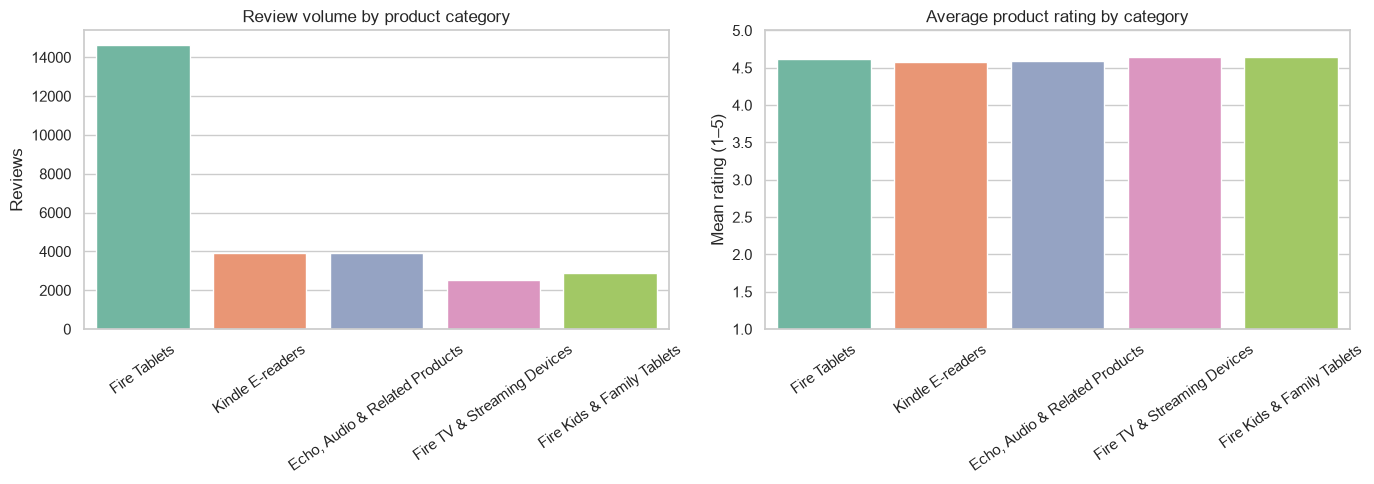


### Fire Tablets — lowest-rated reviewed products


,product_name,review_count,mean_rating,negative_share
2,"All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",212,4.43,8.0%
31,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",10961,4.45,3.0%
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta",146,4.57,2.7%
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",2814,4.59,1.9%
30,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",368,4.60,2.4%


,product_name,rating,review_text
117,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",2.0,didn t have some of the features i was looking...
126,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",1.0,i bought this around black friday for 60 hopin...
169,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",1.0,i bought this tablet for my 4 year old daughte...



### Kindle E-readers — lowest-rated reviewed products


,product_name,review_count,mean_rating,negative_share
34,"Kindle Oasis E-reader with Leather Charging Cover - Black, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers",6,3.83,16.7%
37,"Kindle Paperwhite E-reader - White, 6 High-Resolution Display (300 ppi) with Built-in Light, Wi-Fi - Includes Special Offers",30,4.53,3.3%
35,"Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers",67,4.61,3.0%
5,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,26,4.65,0.0%
38,"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers",580,4.74,0.7%


...

,product_name,review_count,mean_rating,negative_share
19,Amazon Standing Protective Case for Fire HD 6 (4th Generation) - Black,1,4.00,0.0%
21,Certified Refurbished Amazon Fire TV (Previous Generation - 1st),3,4.33,0.0%
15,Amazon Kindle Fire Hd (3rd Generation) 8gb,2,4.50,0.0%
13,Amazon Fire Tv,2528,4.65,1.6%
23,Certified Refurbished Amazon Fire TV with Alexa Voice Remote,4,5.00,0.0%


,product_name,rating,review_text
25399,Amazon Fire Tv,1.0,i tried to set it up for over an hour and it w...
25417,Amazon Fire Tv,2.0,doesn t understand anything i ask and not very...
25474,Amazon Fire Tv,2.0,no matter what i asked either alexa didn t kno...



### Fire Kids & Family Tablets — lowest-rated reviewed products


,product_name,review_count,mean_rating,negative_share
29,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",1685,4.51,3.7%
20,Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,1033,4.55,2.7%
4,"Amazon - Fire 16GB (5th Gen, 2015 Release) - Black",5,4.60,0.0%
11,Amazon Fire Hd 8 8in Tablet 16gb Black B018szt3bk 6th Gen (2016) Android,135,4.74,0.7%
12,"Amazon Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case - Blue",6,4.83,0.0%


,product_name,rating,review_text
14537,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,2.0,bought this for my daughter and she didn t car...
14593,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,2.0,very slow device for most adults probably fine...
14623,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,2.0,use it a lot for listening to audio books too ...


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=profiles, x="category_name", y="total_reviews", hue="category_name", legend=False, ax=axes[0], palette="Set2")
axes[0].set(title="Review volume by product category", xlabel="", ylabel="Reviews")
axes[0].tick_params(axis="x", rotation=35)
sns.barplot(data=profiles, x="category_name", y="mean_rating", hue="category_name", legend=False, ax=axes[1], palette="Set2")
axes[1].set(title="Average product rating by category", xlabel="", ylabel="Mean rating (1–5)", ylim=(1, 5))
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

for category_name in CATEGORY_NAMES.values():
    print(f"\n### {category_name} — lowest-rated reviewed products")
    product_subset = products.loc[products["category_name"].eq(category_name)]
    display(product_subset.sort_values(["mean_rating", "review_count"], ascending=[True, False])[
        ["product_name", "review_count", "mean_rating", "negative_share"]
    ].head(5).style.format({"mean_rating": "{:.2f}", "negative_share": "{:.1%}"}))
    names = set(product_subset["product_name"])
    examples = reviews.loc[
        reviews["product_name"].isin(names) & reviews["rating"].le(2) & reviews["review_text"].str.len().gt(0),
        ["product_name", "rating", "review_text"],
    ].drop_duplicates("review_text").head(3)
    if examples.empty:
        print("No negative review examples in the available records.")
    else:
        display(examples)

## 9. Attach category assignments to reviews and save results

Every review for a named product inherits that product's cluster and reviewed category name. Reviews with unavailable product names are retained as `cluster_id = -1` and `Unclassified / missing product name`; they are not silently forced into a learned category. The CSV outputs provide the assignments, profile statistics, review evidence, and 4–6 cluster comparison.

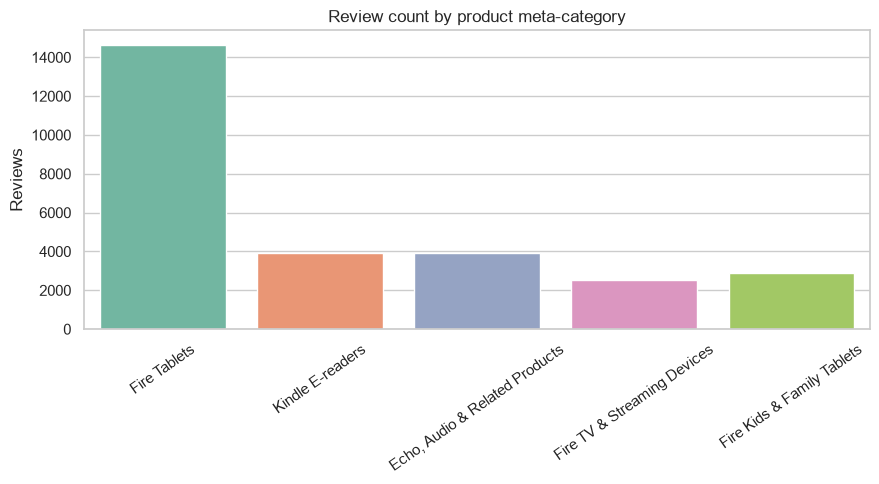

Saved Task 2 files:
- outputs\task2_cluster_solution_comparison.csv
- outputs\task2_cluster_profiles.csv
- outputs\task2_product_clusters.csv
- outputs\task2_review_clusters.csv
- outputs\task2_cluster_review_counts.png
Named products clustered: 40; unclassified reviews: 6,759


In [22]:
profile_lookup = profiles.set_index("cluster_id")["category_name"]
products["cluster_name"] = products["category_name"]

product_assignments = products[[
    "product_name", "cluster_id", "cluster_name", "review_count", "mean_rating",
    "negative_share", "positive_share", "categories_text"
]].copy()
review_assignments = reviews[["product_name", "review_text", "rating", "sentiment"]].merge(
    product_assignments[["product_name", "cluster_id", "cluster_name"]],
    on="product_name", how="left", validate="many_to_one"
)
review_assignments["cluster_id"] = review_assignments["cluster_id"].fillna(-1).astype(int)
review_assignments["cluster_name"] = review_assignments["cluster_name"].fillna(
    "Unclassified / missing product name"
)

cluster_review_counts = (
    review_assignments.loc[review_assignments["cluster_id"].ge(0)]
    .groupby(["cluster_id", "cluster_name"], as_index=False)
    .size().rename(columns={"size": "review_count"})
)
cluster_products = profiles.rename(columns={"category_name": "cluster_name"}).copy()

comparison_path = OUTPUT_DIR / "task2_cluster_solution_comparison.csv"
profiles_path = OUTPUT_DIR / "task2_cluster_profiles.csv"
product_path = OUTPUT_DIR / "task2_product_clusters.csv"
review_path = OUTPUT_DIR / "task2_review_clusters.csv"
solution_comparison.to_csv(comparison_path, index=False)
cluster_products.to_csv(profiles_path, index=False)
product_assignments.to_csv(product_path, index=False)
review_assignments.to_csv(review_path, index=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=cluster_review_counts, x="cluster_name", y="review_count", hue="cluster_name", legend=False, palette="Set2", ax=ax)
ax.set(title="Review count by product meta-category", xlabel="", ylabel="Reviews")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
counts_plot_path = OUTPUT_DIR / "task2_cluster_review_counts.png"
fig.savefig(counts_plot_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved Task 2 files:")
for path in [comparison_path, profiles_path, product_path, review_path, counts_plot_path]:
    print(f"- {path.relative_to(ROOT)}")
print(f"Named products clustered: {len(products):,}; unclassified reviews: {(review_assignments['cluster_id'] == -1).sum():,}")

## 10. Findings and limitations

- Five categories are within the assignment's requested range of 4–6. The result combines title, category metadata, and customer-review text.
- Category names were assigned after inspecting top products and terms. Review the printed cluster contents before using these labels in a report.
- Products can still be cross-category or misplaced: for example, accessories mention the devices they fit, and short or inconsistent product names carry limited information.
- Unknown product names are left unclassified rather than creating a misleading 'unknown product' meta-category.
- This dataset has a limited catalog and product-name corruption; the cluster solution is exploratory. Better product identifiers, richer category metadata, and stakeholder review would improve it.
- The saved `task2_review_clusters.csv` contains review text. Handle it as project data and do not publish raw review excerpts without checking applicable dataset terms and privacy requirements.